In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)


df = pd.read_excel('../data/Baza-walidacyjna1.xlsx')
df.head()


,Szpital,ID,wiek,PSA,data mri,data operacji,PSAdensity,iT,DRE (0-prawidłowe; 1-nieprawidłowe),MRI prostate vol,MRI Pirads IL,MRI EPE (naciek poza torebke),MRI EPE L,MRI EPE P,MRI SVI (pecherzyki),MRI SVI L,MRI SVI P,MRI SIZE INDEX LESION,MAX Bx ISUP Grade L,MAX % L,ilość + wycinków L CEL,ilość + wycinków L REG,ilość + wycinków L SYS,SUMA WYCINKÓW L,MAX Bx ISUP Grade P,MAX % P,ilość + wycinków P CEL,ilość + wycinków P REG,ilość + wycinków P SYS,SUMA WYCINKÓW P,ISUP RP,ISUP RP P,ISUP RP L,SM +,N +,EPE RP,strona EPE RP,EPE RP L,EPE RP P,SVI RP,strona SVI RP,SVI RP L,SVI RP P,TNM
0,Szwajcary,277,73.0,12.00,NaT,NaT,0.480000,2b,0.0,25.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,5.0,2.0,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2
1,Szwajcary,62,56.0,3.50,NaT,NaT,0.102941,2c,0.0,34.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1.0,0.60,2z4,NaN,1z6,NaN,1.0,0.34,2z4,NaN,0z6,NaN,2.0,NaN,NaN,0.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2
2,Szwajcary,64,76.0,8.82,NaT,NaT,0.122500,2b,1.0,72.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,2.0,0.52,3z6,NaN,0z4,NaN,1.0,0.10,NaN,NaN,1z4,NaN,2.0,NaN,NaN,0.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2
3,Szwajcary,65,56.0,5.50,NaT,NaT,0.152778,2c,1.0,36.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,3.0,40.00,5z6,NaN,2z4,NaN,3.0,40.00,5z6,NaN,0z4,NaN,3.0,NaN,NaN,0.0,0.0,1.0,P,0,1,1.0,NaN,NaN,NaN,3a
4,Szwajcary,66,68.0,10.80,NaT,NaT,0.225000,3a,0.0,48.0,5.0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,2.0,0.62,4z6,NaN,0z6,NaN,0.0,0.00,NaN,NaN,0z6,NaN,1.0,NaN,NaN,0.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2


<Axes: xlabel='Szpital'>

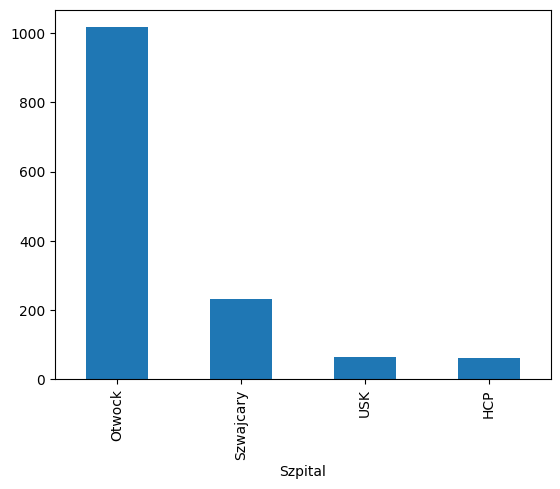

In [19]:
df['Szpital'].value_counts().plot(kind='bar')

In [ ]:
df_train = df[df['Szpital'].isin(['Otwock', 'USK', 'HCP'])]
df_val = df[df['Szpital'].isin(['Szwajcary'])]
print(f"Train set size: {len(df_train)} {len(df_train) / len(df) * 100:.2f}%")
print(f"Validation set size: {len(df_val)} {len(df_val) / len(df) * 100:.2f}%")

Train set size: 1144 83.08%
Validation set size: 233 16.92%


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1377 entries, 0 to 1376
Data columns (total 44 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Szpital                              1377 non-null   object        
 1   ID                                   1377 non-null   object        
 2   wiek                                 1362 non-null   float64       
 3   PSA                                  1361 non-null   float64       
 4   data mri                             601 non-null    datetime64[ns]
 5   data operacji                        975 non-null    datetime64[ns]
 6   PSAdensity                           1278 non-null   float64       
 7   iT                                   1377 non-null   object        
 8   DRE (0-prawidłowe; 1-nieprawidłowe)  531 non-null    float64       
 9   MRI prostate vol                     1281 non-null   float64       
 10  MRI Pirads I

In [35]:
df.columns

Index(['Szpital', 'ID', 'wiek', 'PSA', 'data mri', 'data operacji',
       'PSAdensity', 'iT', 'DRE (0-prawidłowe; 1-nieprawidłowe)',
       'MRI prostate vol', 'MRI Pirads IL', 'MRI EPE (naciek poza torebke)',
       'MRI EPE L', 'MRI EPE P', 'MRI SVI (pecherzyki)', 'MRI SVI L',
       'MRI SVI P', 'MRI SIZE INDEX LESION', 'MAX Bx ISUP Grade L', 'MAX % L',
       'ilość + wycinków L CEL', 'ilość + wycinków L REG',
       'ilość + wycinków L SYS', 'SUMA WYCINKÓW L', 'MAX Bx ISUP Grade P',
       'MAX % P', 'ilość + wycinków P CEL', 'ilość + wycinków P REG',
       'ilość + wycinków P SYS', 'SUMA WYCINKÓW P', 'ISUP RP', 'ISUP RP P',
       'ISUP RP L', 'SM +', 'N +', 'EPE RP', 'strona EPE RP', 'EPE RP L',
       'EPE RP P', 'SVI RP', 'strona SVI RP', 'SVI RP L', 'SVI RP P', 'TNM'],
      dtype='object')

In [38]:
df.columns.tolist()

['Szpital',
 'ID',
 'wiek',
 'PSA',
 'data mri',
 'data operacji',
 'PSAdensity',
 'iT',
 'DRE (0-prawidłowe; 1-nieprawidłowe)',
 'MRI prostate vol',
 'MRI Pirads IL',
 'MRI EPE (naciek poza torebke)',
 'MRI EPE L',
 'MRI EPE P',
 'MRI SVI (pecherzyki)',
 'MRI SVI L',
 'MRI SVI P',
 'MRI SIZE INDEX LESION',
 'MAX Bx ISUP Grade L',
 'MAX % L',
 'ilość\xa0+ wycinków L CEL',
 'ilość\xa0+ wycinków L REG',
 'ilość\xa0+ wycinków L SYS',
 'SUMA WYCINKÓW L',
 'MAX Bx ISUP Grade P',
 'MAX % P',
 'ilość\xa0+ wycinków P CEL',
 'ilość\xa0+ wycinków P REG',
 'ilość\xa0+ wycinków P SYS',
 'SUMA WYCINKÓW P',
 'ISUP RP',
 'ISUP RP P',
 'ISUP RP L',
 'SM +',
 'N +',
 'EPE RP',
 'strona EPE RP',
 'EPE RP L',
 'EPE RP P',
 'SVI RP',
 'strona SVI RP',
 'SVI RP L',
 'SVI RP P',
 'TNM']

In [39]:
df['ilość\xa0+ wycinków L CEL'].unique()

array([6, '2z4', '3z6', '5z6', '4z6', '2z6', '?z12', '5z14', '6z6', '5z8',
       '1z4', '3z3', '4z5', '6z10', '4z8', '1z6', '1z3', '3z10', '10z10',
       '0z10', '6z12', '2z10', '2z12', '1z8', '4z4', '6na6', '4na5',
       '3na3', '2na4', '2na3', '4na6', '5na5', '7na7', '4na4', '3na4',
       '1na3', '3na6', '7na8', '5na6', '2na5', '1na4', '3na5', '5z10',
       nan, '4z10', '5z5', '7z8', '8z8', 2, '5z11', '8z12', '3z12',
       '6z16', '?z22', '4z16', '9z12', '12z12', '4z12', '?z10', '?z11',
       '9z10', 8, 4, 5, '7z10', 9, 1, '8z14', 7, '1z10', '5na7', '2na7',
       '2na2', '3na7', '0na4', 0, '0na6', '1na12', '1na7', '2na8', '9wyc',
       '7na13', '1na1', '5na9', 70, '8na10'], dtype=object)

In [50]:
import re
def clean_wycinki_value(value):
    if pd.isna(value):
        return pd.NA

    s = str(value).strip().lower().replace('\xa0', ' ')
    nums = re.findall(r'\d+', s)

    if len(nums) >= 2:
        x1, x2 = nums[0], nums[1]
    elif len(nums) == 1:
        x1 = x2 = nums[0]
    else:
        return pd.NA

    return f"{int(x1)} {int(x2)}"

In [55]:
df['ilość\xa0+ wycinków L CEL'].apply(clean_wycinki_value).unique()

array(['6 6', '2 4', '3 6', '5 6', '4 6', '2 6', '12 12', '5 14', '5 8',
       '1 4', '3 3', '4 5', '6 10', '4 8', '1 6', '1 3', '3 10', '10 10',
       '0 10', '6 12', '2 10', '2 12', '1 8', '4 4', '2 3', '5 5', '7 7',
       '3 4', '7 8', '2 5', '3 5', '5 10', <NA>, '4 10', '8 8', '2 2',
       '5 11', '8 12', '3 12', '6 16', '22 22', '4 16', '9 12', '4 12',
       '11 11', '9 10', '7 10', '9 9', '1 1', '8 14', '1 10', '5 7',
       '2 7', '3 7', '0 4', '0 0', '0 6', '1 12', '1 7', '2 8', '7 13',
       '5 9', '70 70', '8 10'], dtype=object)

In [56]:
df['ilość\xa0+ wycinków L CEL'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1377 entries, 0 to 1376
Series name: ilość + wycinków L CEL
Non-Null Count  Dtype 
--------------  ----- 
296 non-null    object
dtypes: object(1)
memory usage: 10.9+ KB
